import modules and load the model

In [2]:
import os
from net import Net 
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn.functional as F 
import torch

CLIPSEG_MODEL_PATH = 'CLIPSeg/weights/rd64-uni-refined.pth'
device = 0
'''load model'''
model = Net(CLIPSEG_MODEL_PATH,device)
checkpoint = torch.load('./model/model.pth', weights_only=True)  
model.load_state_dict(checkpoint['model_state_dict'], strict=False)  
model.eval()
model.to(device)
print('done')                                 

done


load images

In [3]:
root_path = './dataset/test'

dataset = 'MFNet'
name = '01264N.png'
ir_path=os.path.join(root_path, dataset, 'ir', name)
vi_path=os.path.join(root_path, dataset, 'vi', name)
text=['enhance the visibility of the image']

ir_image=Image.open(ir_path).convert('L')
vi_image=Image.open(vi_path).convert('RGB')
ir_image=transforms.ToTensor()(ir_image).unsqueeze(0).to(device)
vi_image=transforms.ToTensor()(vi_image).unsqueeze(0).to(device)
print(vi_image.shape)

torch.Size([1, 3, 480, 640])


inference

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.027904186..1.4879327].


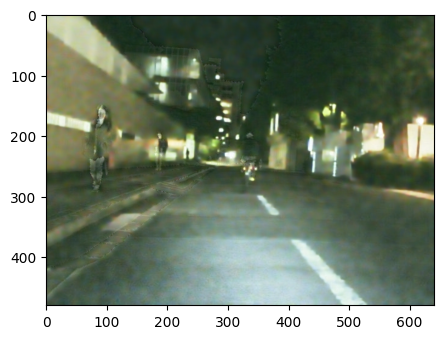

The image is saved to result/MFNet/01264N.png


In [4]:
with torch.no_grad():
    result = model(ir_image, vi_image, text) 

fusion_image=result.squeeze(0).permute(1, 2, 0)
fusion_image=fusion_image.cpu().numpy()

plt.figure(figsize=(5,8))
plt.imshow(fusion_image)  
plt.show()

fusion_image = np.clip(fusion_image * 255, 0, 255).astype(np.uint8)
fusion_image_pil = Image.fromarray(fusion_image, mode='RGB')
save_path = os.path.join('result', dataset)
os.makedirs(save_path, exist_ok=True)
fusion_image_pil.save(os.path.join(save_path, name)) 
print(f'The image is saved to {os.path.join(save_path, name)}')